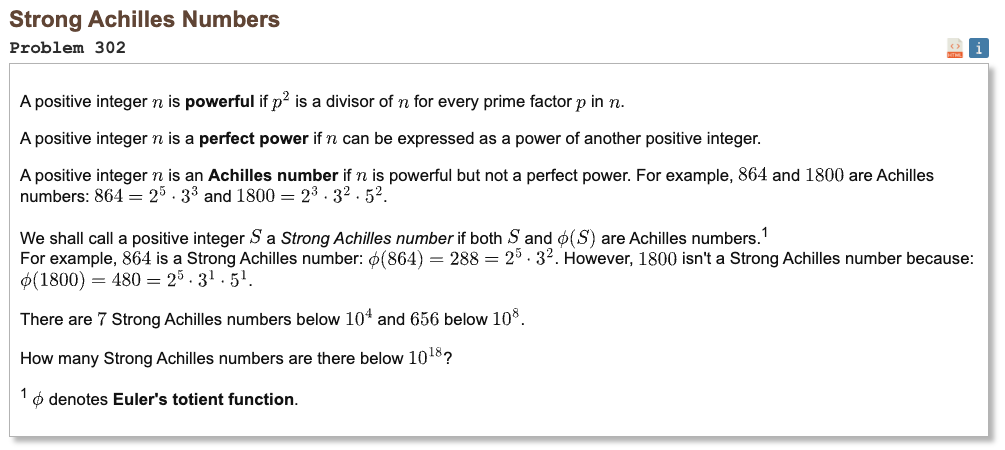

## Initial approach

* represent each candidate by its prime exponents, because an Achilles number is completely determined by those exponents being all at least two but not sharing a common divisor
* build the number prime by prime in increasing order, so each valid factorization is generated exactly once
* track the totient side at the same time, not just the number itself, because the hard part is making the totient also powerful and also not a perfect power
* keep a running record of which primes must appear strongly enough inside the totient, and prune as soon as that requirement becomes too large to ever fit under the limit
* precompute only the primes that can possibly survive that prune, together with the factorization of one less than the prime
* when a full candidate is reached, check the totient exponents directly instead of refactoring the whole number from scratch
* use array from the standard library to store the valid prime table compactly, because the candidate prime list is still fairly large

In [1]:
from math import gcd, isqrt
from array import array

def small_primes(limit):
    sieve = bytearray(b"\x01") * (limit + 1)
    sieve[0:2] = b"\x00\x00"
    for p in range(2, isqrt(limit) + 1):
        if sieve[p]:
            step = p
            start = p * p
            sieve[start:limit + 1:step] = b"\x00" * (((limit - start) // step) + 1)
    return [i for i in range(2, limit + 1) if sieve[i]]

def factorize_with_base(n, base_primes):
    x = n
    factors = []
    rad = 1
    for p in base_primes:
        if p * p > x:
            break
        if x % p == 0:
            e = 0
            rad *= p
            while x % p == 0:
                x //= p
                e += 1
            factors.append((p, e))
    if x > 1:
        rad *= x
        factors.append((x, 1))
    return tuple(factors), rad

def build_valid_primes(limit, phi_rad_limit):
    max_prime = isqrt(limit // 8)
    base_primes = small_primes(isqrt(max_prime) + 1)

    primes = array("I")
    lbs = array("I")
    factors = []

    primes.append(2)
    lbs.append(2)
    factors.append(tuple())

    segment_size = 1_000_000
    low = 3

    while low <= max_prime:
        high = min(low + segment_size - 1, max_prime)
        if low % 2 == 0:
            low += 1
        size = (high - low) // 2 + 1
        sieve = bytearray(b"\x01") * size

        for p in base_primes[1:]:
            pp = p * p
            if pp > high:
                break
            start = max(pp, ((low + p - 1) // p) * p)
            if start % 2 == 0:
                start += p
            idx = (start - low) // 2
            step = p
            while idx < size:
                sieve[idx] = 0
                idx += step

        for i, ok in enumerate(sieve):
            if not ok:
                continue
            p = low + 2 * i
            fac, rad = factorize_with_base(p - 1, base_primes)
            lb = p * rad
            if lb <= phi_rad_limit:
                primes.append(p)
                lbs.append(lb)
                factors.append(fac)

        low = high + 1

    return primes, lbs, factors

def phi_achilles(phi_exp):
    if not phi_exp:
        return False
    g = 0
    for e in phi_exp.values():
        if e < 2:
            return False
        g = gcd(g, e)
    return g == 1

def count_strong_achilles(limit):
    phi_rad_limit = isqrt(limit)
    primes, lbs, factors = build_valid_primes(limit, phi_rad_limit)
    answer = 0

    def dfs(pos, value, g_n, phi_support, phi_exp):
        nonlocal answer

        if g_n == 1 and phi_achilles(phi_exp):
            answer += 1

        min_e = 2
        while g_n and gcd(min_e, g_n) != 1:
            min_e += 1

        bound = int((limit // value) ** (1.0 / min_e)) + 2

        for i in range(pos + 1, len(primes)):
            p = primes[i]
            if p > bound:
                break

            new_support = phi_support * (lbs[i] // gcd(phi_support, lbs[i]))
            if new_support > phi_rad_limit:
                continue

            base_exp = dict(phi_exp)
            for q, e in factors[i]:
                base_exp[q] = base_exp.get(q, 0) + e

            current_value = value * p * p
            if current_value > limit:
                continue

            exp_added_for_phi = 1
            e_n = 2

            while current_value <= limit:
                next_exp = dict(base_exp)
                next_exp[p] = next_exp.get(p, 0) + exp_added_for_phi
                next_g = e_n if g_n == 0 else gcd(g_n, e_n)

                dfs(i, current_value, next_g, new_support, next_exp)

                if current_value > limit // p:
                    break
                current_value *= p
                exp_added_for_phi += 1
                e_n += 1

    dfs(-1, 1, 0, 1, {})
    return answer



```python
%%time
result = count_strong_achilles(10**18)
print("Result:", result)
```

* it takes too long to run  
* to be optimized